In [2]:
!wget -nc https://storage.googleapis.com/tensorflow-1-public/course3/imdb_vocab_subwords.txt

File ‘imdb_vocab_subwords.txt’ already there; not retrieving.



In [5]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import keras_nlp

In [6]:
imdb = tfds.load('imdb_reviews', as_supervised=True, data_dir="./data")

In [7]:
train_reviews = imdb['train'].map(lambda review, label: review)
test_reviews = imdb['test'].map(lambda review, label : review)

train_labels = imdb['train'].map(lambda review, label : label)
test_labels = imdb['test'].map(lambda review, label : label)

In [8]:
subword_tokenizer = keras_nlp.tokenizers.WordPieceTokenizer(vocabulary="./imdb_vocab_subwords.txt")

In [9]:
SHUFFLE_BUFFER_SIZE = 10000
PREFETCH_BUFFER_SIZE = tf.data.AUTOTUNE
BATCH_SIZE = 256
PADDING_TYPE = "pre"
TRUNC_TYPE = "post"

In [10]:
def padding_function(sequences):
  sequences = sequences.ragged_batch(batch_size = sequences.cardinality())
  sequences = sequences.get_single_element()
  padded_sequences = tf.keras.utils.pad_sequences(sequences.numpy(), padding=PADDING_TYPE, truncating=TRUNC_TYPE)
  padded_sequences = tf.data.Dataset.from_tensor_slices(padded_sequences)
  return padded_sequences

In [11]:
train_sequences_subword = train_reviews.map(lambda review: subword_tokenizer.tokenize(review)).apply(padding_function)

In [12]:
test_sequence_subword = test_reviews.map(lambda review: subword_tokenizer.tokenize(review)).apply(padding_function)

In [13]:
train_data_vect = tf.data.Dataset.zip(train_sequences_subword, train_labels)
test_data_vect = tf.data.Dataset.zip(test_sequence_subword, test_labels)

In [14]:
test_data_vect = test_data_vect.batch(BATCH_SIZE).prefetch(PREFETCH_BUFFER_SIZE)
train_data_vect = train_data_vect.shuffle(SHUFFLE_BUFFER_SIZE).batch(BATCH_SIZE).prefetch(PREFETCH_BUFFER_SIZE)

In [16]:
# Parameters
BATCH_SIZE = 1
TIMESTEPS = 20
FEATURES = 20
FILTERS = 128
KERNEL_SIZE = 5

print(f'batch_size: {BATCH_SIZE}')
print(f'timesteps (sequence length): {TIMESTEPS}')
print(f'features (embedding size): {FEATURES}')
print(f'filters: {FILTERS}')
print(f'kernel_size: {KERNEL_SIZE}')
import numpy as np

# Define array input with random values
random_input = np.random.rand(BATCH_SIZE,TIMESTEPS,FEATURES)
print(f'shape of input array: {random_input.shape}')

# Pass array to convolution layer and inspect output shape
conv1d = tf.keras.layers.Conv1D(filters=FILTERS, kernel_size=KERNEL_SIZE, activation='relu')
result = conv1d(random_input)
print(f'shape of conv1d output: {result.shape}')

# Pass array to max pooling layer and inspect output shape
gmp = tf.keras.layers.GlobalMaxPooling1D()
result = gmp(result)
print(f'shape of global max pooling output: {result.shape}')

batch_size: 1
timesteps (sequence length): 20
features (embedding size): 20
filters: 128
kernel_size: 5
shape of input array: (1, 20, 20)
shape of conv1d output: (1, 16, 128)
shape of global max pooling output: (1, 128)


In [17]:
EMBEDDING_DIM = 64
FILTER = 128
KERNEL_SIZE = 5
DENSE_DIM = 64
model = tf.keras.Sequential([
    tf.keras.Input(shape=(None,)),
    tf.keras.layers.Embedding(input_dim=subword_tokenizer.vocabulary_size(), output_dim=EMBEDDING_DIM),
    tf.keras.layers.Conv1D(filters=FILTER, kernel_size=KERNEL_SIZE, activation='relu'),
    tf.keras.layers.GlobalMaxPooling1D(),
    tf.keras.layers.Dense(DENSE_DIM, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, None, 64)       │       488,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, None, 128)      │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 538,049 (2.05 MB)

 Trainable params: 538,049 (2.05 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [19]:
epoches = 5
history = model.fit(train_data_vect, epochs=epoches, validation_data=test_data_vect)

Epoch 1/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 41s 326ms/step - accuracy: 0.7006 - loss: 0.5737 - val_accuracy: 0.8319 - val_loss: 0.3837
Epoch 2/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 27s 267ms/step - accuracy: 0.8775 - loss: 0.2936 - val_accuracy: 0.8880 - val_loss: 0.2672
Epoch 3/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 25s 244ms/step - accuracy: 0.9380 - loss: 0.1698 - val_accuracy: 0.8832 - val_loss: 0.2818
Epoch 4/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 24s 246ms/step - accuracy: 0.9718 - loss: 0.0940 - val_accuracy: 0.8962 - val_loss: 0.2642
Epoch 5/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 25s 249ms/step - accuracy: 0.9936 - loss: 0.0390 - val_accuracy: 0.8914 - val_loss: 0.3077


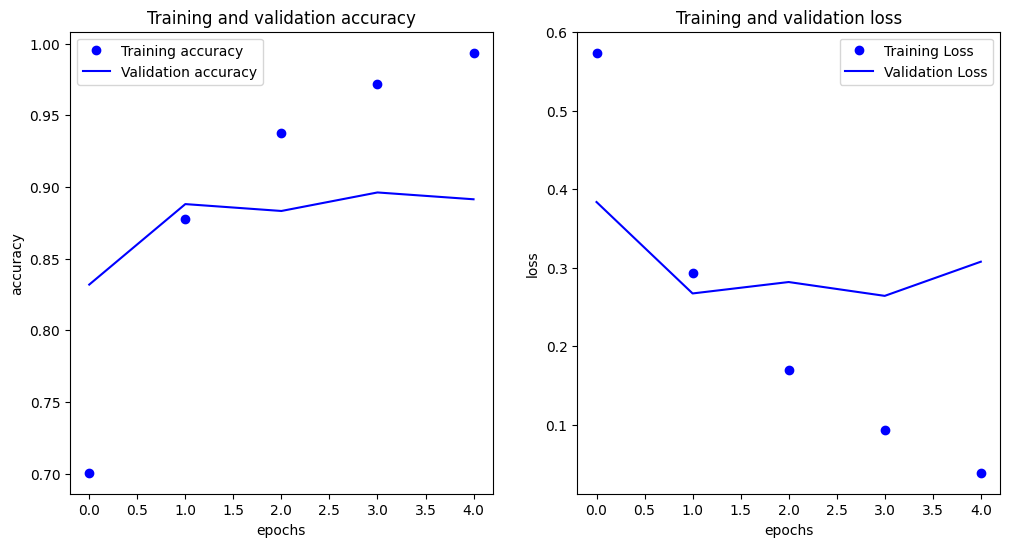

In [20]:
def plot_loss_acc(history):
  '''Plots the training and validation loss and accuracy from a history object'''
  acc = history.history['accuracy']
  val_acc = history.history['val_accuracy']
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  epochs = range(len(acc))

  fig, ax = plt.subplots(1,2, figsize=(12, 6))
  ax[0].plot(epochs, acc, 'bo', label='Training accuracy')
  ax[0].plot(epochs, val_acc, 'b', label='Validation accuracy')
  ax[0].set_title('Training and validation accuracy')
  ax[0].set_xlabel('epochs')
  ax[0].set_ylabel('accuracy')
  ax[0].legend()

  ax[1].plot(epochs, loss, 'bo', label='Training Loss')
  ax[1].plot(epochs, val_loss, 'b', label='Validation Loss')
  ax[1].set_title('Training and validation loss')
  ax[1].set_xlabel('epochs')
  ax[1].set_ylabel('loss')
  ax[1].legend()

  plt.show()

plot_loss_acc(history)

In [21]:
# Shutdown the kernel to free up resources.
# Note: You can expect a pop-up when you run this cell. You can safely ignore that and just press `Ok`.

from IPython import get_ipython

k = get_ipython().kernel

k.do_shutdown(restart=False)

{'status': 'ok', 'restart': False}